In [ ]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"shahdelshafei","key":"14f5ddafb4294a7aa0668177a33ba201"}'}

In [ ]:
import os

# Create Kaggle directory
os.makedirs("/root/.kaggle", exist_ok=True)

# Move kaggle.json
os.rename("kaggle.json", "/root/.kaggle/kaggle.json")

# Set permissions

os.chmod("/root/.kaggle/kaggle.json", 600)


In [ ]:
!kaggle datasets download -d gowrishankarp/newspaper-text-summarization-cnn-dailymail

Dataset URL: https://www.kaggle.com/datasets/gowrishankarp/newspaper-text-summarization-cnn-dailymail
License(s): CC0-1.0
 92% 465M/503M [00:00<00:00, 406MB/s]
100% 503M/503M [00:01<00:00, 460MB/s]


In [ ]:
!unzip newspaper-text-summarization-cnn-dailymail.zip

Archive:  newspaper-text-summarization-cnn-dailymail.zip
  inflating: cnn_dailymail/test.csv  
  inflating: cnn_dailymail/train.csv  
  inflating: cnn_dailymail/validation.csv  


In [ ]:
import pandas as pd

train_df = pd.read_csv("cnn_dailymail/train.csv")[["article", "highlights"]]
val_df   = pd.read_csv("cnn_dailymail/validation.csv")[["article", "highlights"]]
test_df  = pd.read_csv("cnn_dailymail/test.csv")[["article", "highlights"]]


In [ ]:
# Showing a sample of an article and it's highlight
first_article = train_df.loc[0, 'article']
first_summary = train_df.loc[0, 'highlights']

print("First Article:\n", first_article)
print("\nFirst Summary:\n", first_summary)

First Article:
 By . Associated Press . PUBLISHED: . 14:11 EST, 25 October 2013 . | . UPDATED: . 15:36 EST, 25 October 2013 . The bishop of the Fargo Catholic Diocese in North Dakota has exposed potentially hundreds of church members in Fargo, Grand Forks and Jamestown to the hepatitis A virus in late September and early October. The state Health Department has issued an advisory of exposure for anyone who attended five churches and took communion. Bishop John Folda (pictured) of the Fargo Catholic Diocese in North Dakota has exposed potentially hundreds of church members in Fargo, Grand Forks and Jamestown to the hepatitis A . State Immunization Program Manager Molly Howell says the risk is low, but officials feel it's important to alert people to the possible exposure. The diocese announced on Monday that Bishop John Folda is taking time off after being diagnosed with hepatitis A. The diocese says he contracted the infection through contaminated food while attending a conference for 

In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 287113 entries, 0 to 287112
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   article     287113 non-null  object
 1   highlights  287113 non-null  object
dtypes: object(2)
memory usage: 4.4+ MB


We are going to perform simple perprocessing on the data as the genration highlights will require keeping most of the aspects of the original data like the stopwords for example

In [ ]:
import re

class TextPreprocessor:
    def __init__(self, lowercase=True):
        self.lowercase = lowercase

    def normalize_quotes(self, text): # Correctin some of the punctuation
        text = text.replace("“", '"').replace("”", '"')
        text = text.replace("‘", "'").replace("’", "'")
        text = text.replace("—", "-").replace("–", "-")
        return text

    def clean_punctuation(self, text): # Keeping only the common and known punctuation along with the letters, numbers and whitespaces
        return re.sub(r"[^a-zA-Z0-9.,!?'\s]", "", text)

    def preprocess_text(self, text):
        text = text.strip()
        text = self.normalize_quotes(text) # Normalize different quotation mark styles into a consistent format
        text = self.clean_punctuation(text)
        if self.lowercase:
            text = text.lower()
        return text

    def preprocess_dataframe(self, df): # Applying all of the above on the important columns
        df = df.copy()
        df["article"] = df["article"].apply(self.preprocess_text)
        df["highlights"] = df["highlights"].apply(self.preprocess_text)
        return df


In [ ]:
preprocessor = TextPreprocessor(lowercase=True)

train_df = preprocessor.preprocess_dataframe(train_df)
val_df   = preprocessor.preprocess_dataframe(val_df)
test_df  = preprocessor.preprocess_dataframe(test_df)


In [ ]:
from collections import Counter

# Special tokens used to handle padding, sequence boundaries, and unknown words
SPECIAL_TOKENS = ["<pad>", "<sos>", "<eos>", "<unk>"]

def build_vocab(texts, vocab_size=30000):
    counter = Counter()
    for text in texts:
      # Split the text into words and update their frequency counts
        counter.update(text.split())
   # Build the vocabulary
    vocab = SPECIAL_TOKENS + [w for w, _ in counter.most_common(vocab_size)]
    # Create a mapping from word to unique index
    word2idx = {w: i for i, w in enumerate(vocab)}

    # Create the reverse mapping from index to word
    idx2word = {i: w for w, i in word2idx.items()}
    return word2idx, idx2word


In [ ]:
def text_to_sequence(text, word2idx):
    return [word2idx.get(w, word2idx["<unk>"]) for w in text.split()]


In [ ]:
def text_to_sequence(text, word2idx):
    # Converts a text string into a numerical sequence using a word-to-index mapping.
    # 'text' is the input string, 'word2idx' is the vocabulary dictionary.
    return [
        word2idx.get(w, word2idx["<unk>"]) # Get index for word 'w', default to <unk> if not found.
        for w in text.split() # Split the input text into individual words.
    ]

In [ ]:
# Prepare the data of the RNN
def prepare_rnn_data(df, word2idx, max_art_len, max_sum_len):
    encoder_inputs = []
    decoder_inputs = []
    decoder_targets = []

    for _, row in df.iterrows():
        enc = text_to_sequence(row.article, word2idx)
        dec = text_to_sequence(row.highlights, word2idx)

        enc = enc[:max_art_len]
        dec = dec[:max_sum_len]

        encoder_inputs.append(enc)
        decoder_inputs.append([word2idx["<sos>"]] + dec)
        decoder_targets.append(dec + [word2idx["<eos>"]])

    return encoder_inputs, decoder_inputs, decoder_targets


In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
MAX_ART_LEN = 100
MAX_SUM_LEN = 30

# Sample a smaller subset of the training data to speed up execution
sampled_train_df = train_df.sample(frac=0.05, random_state=42)

word2idx, idx2word = build_vocab(sampled_train_df.article) # Get word2idx and idx2word

enc_train, dec_in_train, dec_out_train = prepare_rnn_data(
    sampled_train_df, word2idx, MAX_ART_LEN, MAX_SUM_LEN
)

enc_train = pad_sequences(enc_train,  padding="post")
dec_in_train = pad_sequences(dec_in_train, maxlen=MAX_SUM_LEN+1, padding="post")
dec_out_train = pad_sequences(dec_out_train, maxlen=MAX_SUM_LEN+1, padding="post")

In [ ]:
enc_train.shape

(14356, 100)

In [ ]:
# Sample a smaller subset of the validation data
# We are taking only 5% of the data
sampled_val_df = val_df.sample(frac=0.05, random_state=42)

enc_val, dec_in_val, dec_out_val = prepare_rnn_data(
    sampled_val_df, word2idx, MAX_ART_LEN, MAX_SUM_LEN
)

enc_val = pad_sequences(enc_val,  padding="post")
dec_in_val = pad_sequences(dec_in_val, maxlen=MAX_SUM_LEN+1, padding="post")
dec_out_val = pad_sequences(dec_out_val, maxlen=MAX_SUM_LEN+1, padding="post")

In [ ]:
enc_val.shape

(668, 100)

In [ ]:
# Sample a smaller subset of the test data
sampled_test_df = test_df.sample(frac=0.05, random_state=42)

enc_test, dec_in_test, dec_out_test = prepare_rnn_data(
    sampled_test_df, word2idx, MAX_ART_LEN, MAX_SUM_LEN
)

enc_test = pad_sequences(enc_test,  padding="post")
dec_in_test = pad_sequences(dec_in_test, maxlen=MAX_SUM_LEN+1, padding="post")
dec_out_test = pad_sequences(dec_out_test, maxlen=MAX_SUM_LEN+1, padding="post")

In [ ]:
enc_test.shape

(574, 100)

#**Models implementaion**

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np

# Define hyperparameters
embedding_dim = 128
rnn_units = 256
batch_size = 64
epochs = 20
MAX_ART_LEN = 100
MAX_SUM_LEN = 30

# vocabulary size
vocab_size = len(word2idx)

# Define ZerosLikeLayer (Creates a new layer by inheriting from layers.Layer)
# Create an initial hidden state for an RNN
class ZerosLikeLayer(layers.Layer):
  # Stores how long the output vector should be.
    def __init__(self, output_dim, **kwargs):
        super(ZerosLikeLayer, self).__init__(**kwargs)
        self.output_dim = output_dim
    # Creates a single zero vector
    def build(self, input_shape):
        self.zeros = self.add_weight(
            shape=(1, self.output_dim),
            initializer='zeros',
            trainable=False,
            name='zeros'
        )

    # Produces the actual output when the layer is used.
    def call(self, inputs):
        batch_size_tensor = tf.shape(inputs)[0]
        return tf.tile(self.zeros, [batch_size_tensor, 1])

   # Allows the model to be saved and loaded correctly
    def get_config(self):
        config = super(ZerosLikeLayer, self).get_config()
        config.update({
            'output_dim': self.output_dim,
        })
        return config

# Print hyperparameters to verify
print(f"Embedding Dimension: {embedding_dim}")
print(f"RNN Units: {rnn_units}")
print(f"Batch Size: {batch_size}")
print(f"Epochs: {epochs}")
print(f"Max Article Length: {MAX_ART_LEN}")
print(f"Max Summary Length: {MAX_SUM_LEN}")
print(f"Vocabulary Size: {vocab_size}")

Embedding Dimension: 128
RNN Units: 256
Batch Size: 64
Epochs: 20
Max Article Length: 100
Max Summary Length: 30
Vocabulary Size: 30004


In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
import tensorflow as tf

# 1. Reprocess training data with updated MAX_ART_LEN and MAX_SUM_LEN
enc_train, dec_in_train, dec_out_train = prepare_rnn_data(
    sampled_train_df, word2idx, MAX_ART_LEN, MAX_SUM_LEN
)

# 2. Reprocess validation data with updated MAX_ART_LEN and MAX_SUM_LEN
enc_val, dec_in_val, dec_out_val = prepare_rnn_data(
    sampled_val_df, word2idx, MAX_ART_LEN, MAX_SUM_LEN
)

# 3. Pad encoder training and validation sequences
enc_train_pad = pad_sequences(enc_train, maxlen=MAX_ART_LEN, padding="post")
enc_val_pad   = pad_sequences(enc_val, maxlen=MAX_ART_LEN, padding="post")

# 4. Pad decoder input training and validation sequences
dec_in_train_pad = pad_sequences(dec_in_train, maxlen=MAX_SUM_LEN + 1, padding="post")
dec_in_val_pad   = pad_sequences(dec_in_val, maxlen=MAX_SUM_LEN + 1, padding="post")

# 5. Pad decoder output training and validation sequences
dec_out_train_pad = pad_sequences(dec_out_train, maxlen=MAX_SUM_LEN + 1, padding="post")
dec_out_val_pad   = pad_sequences(dec_out_val, maxlen=MAX_SUM_LEN + 1, padding="post")

# 6. Create tf.data.Dataset for training data
train_dataset = tf.data.Dataset.from_tensor_slices(
    ({"encoder_input": enc_train_pad, "decoder_input": dec_in_train_pad}, dec_out_train_pad)
)
train_dataset = train_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

# 7. Create tf.data.Dataset for validation data
val_dataset = tf.data.Dataset.from_tensor_slices(
    ({"encoder_input": enc_val_pad, "decoder_input": dec_in_val_pad}, dec_out_val_pad)
)
val_dataset = val_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

print("Training and validation data reprocessed, padded, and converted to tf.data.Dataset objects.")
print(f"Shape of padded encoder training data: {enc_train_pad.shape}")
print(f"Shape of padded decoder input training data: {dec_in_train_pad.shape}")
print(f"Shape of padded decoder output training data: {dec_out_train_pad.shape}")
print(f"Shape of padded encoder validation data: {enc_val_pad.shape}")
print(f"Shape of padded decoder input validation data: {dec_in_val_pad.shape}")
print(f"Shape of padded decoder output validation data: {dec_out_val_pad.shape}")


Training and validation data reprocessed, padded, and converted to tf.data.Dataset objects.
Shape of padded encoder training data: (14356, 100)
Shape of padded decoder input training data: (14356, 31)
Shape of padded decoder output training data: (14356, 31)
Shape of padded encoder validation data: (668, 100)
Shape of padded decoder input validation data: (668, 31)
Shape of padded decoder output validation data: (668, 31)


In [ ]:
epochs = 10
print(f"Epochs updated to: {epochs}")

Epochs updated to: 10


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

# Define build_seq2seq_rnn_baseline function
def build_seq2seq_rnn_baseline(vocab_size, embedding_dim, rnn_units, max_art_len, max_sum_len):
    # Encoder
    encoder_inputs = layers.Input(shape=(max_art_len,), name='encoder_input')
    enc_embedding = layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim, mask_zero=True)(encoder_inputs)
    _, encoder_state_h = layers.SimpleRNN(units=rnn_units, return_sequences=False, return_state=True)(enc_embedding)

    # Decoder
    decoder_inputs = layers.Input(shape=(max_sum_len + 1,), name='decoder_input')
    dec_embedding = layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim, mask_zero=True)(decoder_inputs)

    # Use ZerosLikeLayer for the initial state of the decoder SimpleRNN
    #initial_decoder_state = ZerosLikeLayer(output_dim=rnn_units)(encoder_state_h)

    decoder_rnn_outputs = layers.SimpleRNN(units=rnn_units, return_sequences=True)(
        dec_embedding, initial_state=encoder_state_h
    )
    decoder_outputs = layers.Dense(units=vocab_size, activation='softmax')(decoder_rnn_outputs)

    # Model
    model = tf.keras.Model(inputs=[encoder_inputs, decoder_inputs], outputs=decoder_outputs)

    # Compile the model
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    return model

# Instantiate the baseline SimpleRNN model
baseline_model = build_seq2seq_rnn_baseline(
    vocab_size, embedding_dim, rnn_units, MAX_ART_LEN, MAX_SUM_LEN
)
print("Baseline SimpleRNN model instantiated.")

# Create EarlyStopping callback for the baseline model
early_stopping_baseline = EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)
print("EarlyStopping callback for baseline model created.")

# Train the baseline model
print("Training baseline SimpleRNN model...")
history_baseline = baseline_model.fit(
    train_dataset,
    epochs=epochs, # epochs is already set to 10
    validation_data=val_dataset,
    callbacks=[early_stopping_baseline]
)
print("Baseline SimpleRNN model training complete.")

Baseline SimpleRNN model instantiated.
EarlyStopping callback for baseline model created.
Training baseline SimpleRNN model...
Epoch 1/10
  1/225 ━━━━━━━━━━━━━━━━━━━━ 2:32 680ms/step - accuracy: 5.0403e-04 - loss: 10.3093

/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:855: UserWarning: Gradients do not exist for variables ['embedding_58/embeddings', 'simple_rnn_12/simple_rnn_cell/kernel', 'simple_rnn_12/simple_rnn_cell/recurrent_kernel', 'simple_rnn_12/simple_rnn_cell/bias'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


 28/225 ━━━━━━━━━━━━━━━━━━━━ 2:03 628ms/step - accuracy: 0.0281 - loss: 9.4564

ERROR:tensorflow:==================================
Object was never used (type <class 'tensorflow.python.ops.tensor_array_ops.TensorArray'>):
If you want to mark it as used call its "mark_used()" method.
It was originally created here:
  File "/usr/local/lib/python3.12/dist-packages/tensorflow/python/ops/while_loop.py", line 488, in while_loop
    loop_vars = body(*loop_vars)  File "/usr/local/lib/python3.12/dist-packages/tensorflow/python/ops/while_loop.py", line 479, in <lambda>
    body = lambda i, lv: (i + 1, orig_body(*lv))  File "/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/rnn.py", line 426, in _step
    return (time + 1, output_ta_t) + tuple(new_states)  File "/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/rnn.py", line 420, in <genexpr>
    for ta, out in zip(output_ta_t, flat_output)  File "/usr/local/lib/python3.12/dist-packages/tensorflow/python/util/tf_should_use.py", line 288, in wrapped
    return _add_should_use_warning(fn(

225/225 ━━━━━━━━━━━━━━━━━━━━ 151s 671ms/step - accuracy: 0.0514 - loss: 7.8619 - val_accuracy: 0.0696 - val_loss: 7.0695
Epoch 2/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 151s 672ms/step - accuracy: 0.0771 - loss: 7.0874 - val_accuracy: 0.1157 - val_loss: 6.7413
Epoch 3/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 150s 665ms/step - accuracy: 0.1147 - loss: 6.7475 - val_accuracy: 0.1439 - val_loss: 6.4494
Epoch 4/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 151s 670ms/step - accuracy: 0.1369 - loss: 6.4495 - val_accuracy: 0.1506 - val_loss: 6.2910
Epoch 5/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 151s 670ms/step - accuracy: 0.1464 - loss: 6.2348 - val_accuracy: 0.1702 - val_loss: 6.1700
Epoch 6/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 150s 668ms/step - accuracy: 0.1658 - loss: 6.0447 - val_accuracy: 0.1801 - val_loss: 6.1083
Epoch 7/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 151s 671ms/step - accuracy: 0.1744 - loss: 5.8862 - val_accuracy: 0.1838 - val_loss: 6.0681
Epoch 8/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 150s 668ms/step - accuracy: 0.1823 - loss: 5.73

In [ ]:
baseline_model.save('baseline_rnn_model.keras')
print("Baseline RNN model saved successfully as 'baseline_rnn_model.keras'")

Baseline RNN model saved successfully as 'baseline_rnn_model.keras'


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

# Define build_seq2seq_rnn_with_attention function
def build_seq2seq_rnn_with_attention(vocab_size, embedding_dim, rnn_units, max_art_len, max_sum_len):
    # Encoder
    encoder_inputs = layers.Input(shape=(max_art_len,), name='encoder_input')
    # Removed mask_zero=True to disable masking and bypass the error
    enc_embedding_output = layers.Embedding(
        input_dim=vocab_size, output_dim=embedding_dim
    )(encoder_inputs)
    encoder_outputs, encoder_state_h = layers.SimpleRNN(
        units=rnn_units, return_sequences=True, return_state=True, name='encoder_rnn'
    )(enc_embedding_output)

    # Decoder
    decoder_inputs = layers.Input(shape=(max_sum_len + 1,), name='decoder_input')
    # Removed mask_zero=True to disable masking and bypass the error
    dec_embedding_output = layers.Embedding(
        input_dim=vocab_size, output_dim=embedding_dim
    )(decoder_inputs)
    decoder_rnn_outputs = layers.SimpleRNN(
        units=rnn_units, return_sequences=True, name='decoder_rnn'
    )(
        dec_embedding_output, initial_state=encoder_state_h
    )

    # Attention Mechanism
    # Removed explicit `mask` argument and disabled mask_zero in Embedding layers
    # to avoid the InvalidArgumentError in AdditiveAttention.
    attention_output = layers.AdditiveAttention(name='attention_layer')(
        [decoder_rnn_outputs, encoder_outputs, encoder_outputs]
    )

    # Concatenate attention output with decoder RNN outputs
    decoder_concat_output = layers.Concatenate(axis=-1, name='decoder_concat_attention')([
        decoder_rnn_outputs, attention_output
    ])

    # Output Layer
    decoder_outputs = layers.Dense(
        units=vocab_size, activation='softmax', name='decoder_output_dense'
    )(decoder_concat_output)

    # Model
    model = tf.keras.Model(inputs=[encoder_inputs, decoder_inputs], outputs=decoder_outputs)

    # Compile the model
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    return model

# Instantiate the SimpleRNN with attention model
attention_model = build_seq2seq_rnn_with_attention(
    vocab_size, embedding_dim, rnn_units, MAX_ART_LEN, MAX_SUM_LEN
)
print("SimpleRNN with Attention model instantiated.")

# Create EarlyStopping callback for the attention model
early_stopping_attention = EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)
print("EarlyStopping callback for attention model created.")

# Train the attention model
print("Training SimpleRNN with Attention model...")
history_attention = attention_model.fit(
    train_dataset,
    epochs=epochs,
    validation_data=val_dataset,
    callbacks=[early_stopping_attention]
)
print("SimpleRNN with Attention model training complete.")

# Save the attention model
attention_model.save('attention_rnn_model.keras')
print("Attention RNN model saved successfully as 'attention_rnn_model.keras'")

SimpleRNN with Attention model instantiated.
EarlyStopping callback for attention model created.
Training SimpleRNN with Attention model...
Epoch 1/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 39s 134ms/step - accuracy: 0.0739 - loss: 7.6554 - val_accuracy: 0.1539 - val_loss: 6.4816
Epoch 2/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 24s 107ms/step - accuracy: 0.1540 - loss: 6.4275 - val_accuracy: 0.1762 - val_loss: 6.1592
Epoch 3/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 25s 110ms/step - accuracy: 0.1798 - loss: 6.0525 - val_accuracy: 0.1907 - val_loss: 6.0281
Epoch 4/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 26s 114ms/step - accuracy: 0.1922 - loss: 5.8098 - val_accuracy: 0.1953 - val_loss: 5.9736
Epoch 5/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 26s 114ms/step - accuracy: 0.2020 - loss: 5.6064 - val_accuracy: 0.2002 - val_loss: 5.9444
Epoch 6/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 25s 113ms/step - accuracy: 0.2094 - loss: 5.4230 - val_accuracy: 0.2013 - val_loss: 5.9442
Epoch 7/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 25s 113ms/step - accuracy: 0.2153 

In [ ]:
import numpy as np

# Extract training and validation accuracy for the baseline model
baseline_train_accuracy = history_baseline.history['accuracy']
baseline_val_accuracy = history_baseline.history['val_accuracy']

# Extract training and validation accuracy for the attention model
attention_train_accuracy = history_attention.history['accuracy']
attention_val_accuracy = history_attention.history['val_accuracy']

print("Training and validation accuracies extracted for both models.")
print(f"Baseline Train Accuracy (last): {np.mean(baseline_train_accuracy[-5:]):.4f}")
print(f"Baseline Val Accuracy (last): {np.mean(baseline_val_accuracy[-5:]):.4f}")
print(f"Attention Train Accuracy (last): {np.mean(attention_train_accuracy[-5:]):.4f}")
print(f"Attention Val Accuracy (last): {np.mean(attention_val_accuracy[-5:]):.4f}")

Training and validation accuracies extracted for both models.
Baseline Train Accuracy (last): 0.1830
Baseline Val Accuracy (last): 0.1850
Attention Train Accuracy (last): 0.2128
Attention Val Accuracy (last): 0.1961


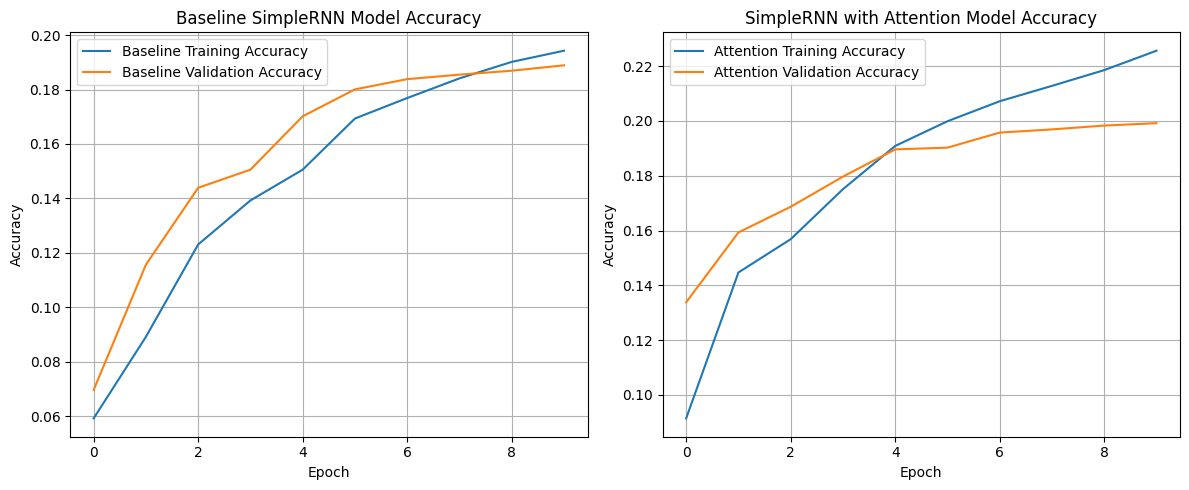

Training and validation accuracy plots generated for both models.


In [ ]:
import matplotlib.pyplot as plt

# Create a figure with two subplots
plt.figure(figsize=(12, 5))

# Plot for Baseline SimpleRNN Model
plt.subplot(1, 2, 1)
plt.plot(baseline_train_accuracy, label='Baseline Training Accuracy')
plt.plot(baseline_val_accuracy, label='Baseline Validation Accuracy')
plt.title('Baseline SimpleRNN Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot for SimpleRNN with Attention Model
plt.subplot(1, 2, 2)
plt.plot(attention_train_accuracy, label='Attention Training Accuracy')
plt.plot(attention_val_accuracy, label='Attention Validation Accuracy')
plt.title('SimpleRNN with Attention Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("Training and validation accuracy plots generated for both models.")

In [ ]:
def summarize_text(input_article, model, word2idx, idx2word, max_art_len, max_sum_len, preprocessor):
    # Preprocess the input article
    preprocessed_article = preprocessor.preprocess_text(input_article)

    # Convert article to sequence
    encoder_input_seq = text_to_sequence(preprocessed_article, word2idx)
    encoder_input_seq = pad_sequences([encoder_input_seq], maxlen=max_art_len, padding='post')

    # Initialize decoder input with <sos> token
    decoder_input_sequence = np.zeros((1, max_sum_len + 1), dtype='int32')
    decoder_input_sequence[0, 0] = word2idx['<sos>']

    summary_tokens = []

    for i in range(1, max_sum_len + 1):
        # Predict the next word
        predictions = model.predict([encoder_input_seq, decoder_input_sequence], verbose=0)

        # Get the word with the highest probability at the current time step
        predicted_token_index = np.argmax(predictions[0, i-1, :])

        # Convert token index to word
        predicted_word = idx2word.get(predicted_token_index, '<unk>')

        # Break if <eos> token is predicted
        if predicted_word == '<eos>':
            break

        summary_tokens.append(predicted_word)

        # Update the decoder input sequence for the next prediction
        if i < max_sum_len + 1:
            decoder_input_sequence[0, i] = predicted_token_index

    return ' '.join(summary_tokens)


In [ ]:
# Example usage:
user_article = input("Enter the article you want to summarize: ")

# Ensure the preprocessor object is available (it should be from earlier cells)
# preprocessor = TextPreprocessor(lowercase=True) # Uncomment if you need to re-initialize

if 'preprocessor' not in locals():
    print("TextPreprocessor object not found. Please run the preprocessing cells first.")
else:
    generated_summary = summarize_text(
        user_article,
        attention_model, # Using the attention model for summarization
        word2idx,
        idx2word,
        MAX_ART_LEN,
        MAX_SUM_LEN,
        preprocessor
    )
    print("\nGenerated Summary:", generated_summary)


Enter the article you want to summarize: WASHINGTON — The White House announced new environmental regulations on Monday aimed at reducing carbon emissions from power plants. The new rules are expected to cut emissions by nearly 30 percent over the next decade. President Biden emphasized the importance of combating climate change while ensuring economic growth. Industry leaders expressed concern about potential costs, but environmental groups praised the move as a necessary step toward sustainability. Lawmakers on both sides of the aisle are expected to debate the regulations in the coming weeks.

Generated Summary: <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> . <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> says .


# The coming code is for the addressing of the unknown output

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
MAX_ART_LEN = 100
MAX_SUM_LEN = 30

# Sample a smaller subset of the training data to speed up execution
sampled_train_df = train_df.sample(frac=0.20, random_state=42)

word2idx, idx2word = build_vocab(sampled_train_df.article) # Get word2idx and idx2word

enc_train, dec_in_train, dec_out_train = prepare_rnn_data(
    sampled_train_df, word2idx, MAX_ART_LEN, MAX_SUM_LEN
)

enc_train = pad_sequences(enc_train,  padding="post")
dec_in_train = pad_sequences(dec_in_train, maxlen=MAX_SUM_LEN+1, padding="post")
dec_out_train = pad_sequences(dec_out_train, maxlen=MAX_SUM_LEN+1, padding="post")

In [ ]:
# Sample a smaller subset of the validation data
# We are taking only 20% of the data
sampled_val_df = val_df.sample(frac=0.20, random_state=42)

enc_val, dec_in_val, dec_out_val = prepare_rnn_data(
    sampled_val_df, word2idx, MAX_ART_LEN, MAX_SUM_LEN
)

enc_val = pad_sequences(enc_val,  padding="post")
dec_in_val = pad_sequences(dec_in_val, maxlen=MAX_SUM_LEN+1, padding="post")
dec_out_val = pad_sequences(dec_out_val, maxlen=MAX_SUM_LEN+1, padding="post")

In [ ]:
import pandas as pd
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Sample a smaller subset of the test data
sampled_test_df = test_df.sample(frac=0.20, random_state=42)

enc_test, dec_in_test, dec_out_test = prepare_rnn_data(
    sampled_test_df, word2idx, MAX_ART_LEN, MAX_SUM_LEN
)

enc_test = pad_sequences(enc_test,  padding="post")
dec_in_test = pad_sequences(dec_in_test, maxlen=MAX_SUM_LEN+1, padding="post")
dec_out_test = pad_sequences(dec_out_test, maxlen=MAX_SUM_LEN+1, padding="post")

In [ ]:
enc_train.shape

(57423, 100)

In [ ]:
enc_val.shape

(2674, 100)

In [ ]:
enc_test.shape

(2298, 100)

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
import tensorflow as tf

# 1. Reprocess training data with updated MAX_ART_LEN and MAX_SUM_LEN
enc_train, dec_in_train, dec_out_train = prepare_rnn_data(
    sampled_train_df, word2idx, MAX_ART_LEN, MAX_SUM_LEN
)

# 2. Reprocess validation data with updated MAX_ART_LEN and MAX_SUM_LEN
enc_val, dec_in_val, dec_out_val = prepare_rnn_data(
    sampled_val_df, word2idx, MAX_ART_LEN, MAX_SUM_LEN
)

# 3. Pad encoder training and validation sequences
enc_train_pad = pad_sequences(enc_train, maxlen=MAX_ART_LEN, padding="post")
enc_val_pad   = pad_sequences(enc_val, maxlen=MAX_ART_LEN, padding="post")

# 4. Pad decoder input training and validation sequences
dec_in_train_pad = pad_sequences(dec_in_train, maxlen=MAX_SUM_LEN + 1, padding="post")
dec_in_val_pad   = pad_sequences(dec_in_val, maxlen=MAX_SUM_LEN + 1, padding="post")

# 5. Pad decoder output training and validation sequences
dec_out_train_pad = pad_sequences(dec_out_train, maxlen=MAX_SUM_LEN + 1, padding="post")
dec_out_val_pad   = pad_sequences(dec_out_val, maxlen=MAX_SUM_LEN + 1, padding="post")

# 6. Create tf.data.Dataset for training data
train_dataset = tf.data.Dataset.from_tensor_slices(
    ({"encoder_input": enc_train_pad, "decoder_input": dec_in_train_pad}, dec_out_train_pad)
)
train_dataset = train_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

# 7. Create tf.data.Dataset for validation data
val_dataset = tf.data.Dataset.from_tensor_slices(
    ({"encoder_input": enc_val_pad, "decoder_input": dec_in_val_pad}, dec_out_val_pad)
)
val_dataset = val_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

print("Training and validation data reprocessed, padded, and converted to tf.data.Dataset objects.")
print(f"Shape of padded encoder training data: {enc_train_pad.shape}")
print(f"Shape of padded decoder input training data: {dec_in_train_pad.shape}")
print(f"Shape of padded decoder output training data: {dec_out_train_pad.shape}")
print(f"Shape of padded encoder validation data: {enc_val_pad.shape}")
print(f"Shape of padded decoder input validation data: {dec_in_val_pad.shape}")
print(f"Shape of padded decoder output validation data: {dec_out_val_pad.shape}")

Training and validation data reprocessed, padded, and converted to tf.data.Dataset objects.
Shape of padded encoder training data: (57423, 100)
Shape of padded decoder input training data: (57423, 31)
Shape of padded decoder output training data: (57423, 31)
Shape of padded encoder validation data: (2674, 100)
Shape of padded decoder input validation data: (2674, 31)
Shape of padded decoder output validation data: (2674, 31)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

# Define build_seq2seq_rnn_with_attention function
def build_seq2seq_rnn_with_attention(vocab_size, embedding_dim, rnn_units, max_art_len, max_sum_len):
    # Encoder
    encoder_inputs = layers.Input(shape=(max_art_len,), name='encoder_input')
    # Removed mask_zero=True to disable masking and bypass the error
    enc_embedding_output = layers.Embedding(
        input_dim=vocab_size, output_dim=embedding_dim
    )(encoder_inputs)
    encoder_outputs, encoder_state_h = layers.SimpleRNN(
        units=rnn_units, return_sequences=True, return_state=True, name='encoder_rnn'
    )(enc_embedding_output)

    # Decoder
    decoder_inputs = layers.Input(shape=(max_sum_len + 1,), name='decoder_input')
    # Removed mask_zero=True to disable masking and bypass the error
    dec_embedding_output = layers.Embedding(
        input_dim=vocab_size, output_dim=embedding_dim
    )(decoder_inputs)
    decoder_rnn_outputs = layers.SimpleRNN(
        units=rnn_units, return_sequences=True, name='decoder_rnn'
    )(
        dec_embedding_output, initial_state=encoder_state_h
    )

    # Attention Mechanism
    # Removed explicit `mask` argument and disabled mask_zero in Embedding layers
    # to avoid the InvalidArgumentError in AdditiveAttention.
    attention_output = layers.AdditiveAttention(name='attention_layer')(
        [decoder_rnn_outputs, encoder_outputs, encoder_outputs]
    )

    # Concatenate attention output with decoder RNN outputs
    decoder_concat_output = layers.Concatenate(axis=-1, name='decoder_concat_attention')([
        decoder_rnn_outputs, attention_output
    ])

    # Output Layer
    decoder_outputs = layers.Dense(
        units=vocab_size, activation='softmax', name='decoder_output_dense'
    )(decoder_concat_output)

    # Model
    model = tf.keras.Model(inputs=[encoder_inputs, decoder_inputs], outputs=decoder_outputs)

    # Compile the model
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    return model

# Instantiate the SimpleRNN with attention model
attention_model = build_seq2seq_rnn_with_attention(
    vocab_size, embedding_dim, rnn_units, MAX_ART_LEN, MAX_SUM_LEN
)
print("SimpleRNN with Attention model instantiated.")

# Create EarlyStopping callback for the attention model
early_stopping_attention = EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)
print("EarlyStopping callback for attention model created.")

# Train the attention model
print("Training SimpleRNN with Attention model...")
history_attention = attention_model.fit(
    train_dataset,
    epochs=epochs,
    validation_data=val_dataset,
    callbacks=[early_stopping_attention]
)
print("SimpleRNN with Attention model training complete.")

# Save the attention model
attention_model.save('attention_rnn_model.keras')
print("Attention RNN model saved successfully as 'attention_rnn_model.keras'")

SimpleRNN with Attention model instantiated.
EarlyStopping callback for attention model created.
Training SimpleRNN with Attention model...
Epoch 1/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 113s 120ms/step - accuracy: 0.1184 - loss: 6.9170 - val_accuracy: 0.1892 - val_loss: 6.0400
Epoch 2/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 102s 113ms/step - accuracy: 0.2011 - loss: 5.9408 - val_accuracy: 0.2065 - val_loss: 5.6144
Epoch 3/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 102s 113ms/step - accuracy: 0.2188 - loss: 5.5068 - val_accuracy: 0.2236 - val_loss: 5.4059
Epoch 4/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 102s 113ms/step - accuracy: 0.2303 - loss: 5.2552 - val_accuracy: 0.2272 - val_loss: 5.3609
Epoch 5/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 102s 113ms/step - accuracy: 0.2372 - loss: 5.0733 - val_accuracy: 0.2297 - val_loss: 5.3314
Epoch 6/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 102s 113ms/step - accuracy: 0.2448 - loss: 4.8940 - val_accuracy: 0.2310 - val_loss: 5.3292
Epoch 7/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 102s 113ms/step - accuracy: 

In [ ]:
# Example usage:
user_article = input("Enter the article you want to summarize: ")

# Ensure the preprocessor object is available (it should be from earlier cells)
# preprocessor = TextPreprocessor(lowercase=True) # Uncomment if you need to re-initialize

if 'preprocessor' not in locals():
    print("TextPreprocessor object not found. Please run the preprocessing cells first.")
else:
    generated_summary = summarize_text(
        user_article,
        attention_model, # Using the attention model for summarization
        word2idx,
        idx2word,
        MAX_ART_LEN,
        MAX_SUM_LEN,
        preprocessor
    )
    print("\nGenerated Summary:", generated_summary)


Enter the article you want to summarize: NEW YORK — Tech company Innovatech revealed its latest smartphone on Tuesday, featuring a faster processor and improved camera.

Generated Summary: new york city council says the new york city will be <unk> . new york city council says it will be <unk> . new york city council says it will
